In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
import psutil
from scipy.stats import zscore

import torch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA

sc.settings.verbosity = 3

13:58:20 - INFO - Old pandas version detected. Patching DataFrame.map to DataFrame.applymap
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# SCENIC TFs

In [2]:
# read tf list
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
print(f"{len(tf_list)=}")
tf_list[:10]

len(tf_list)=1892


['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

# # Define Marker Genes from DEG

In [3]:
# %%time
# fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/sample_1_adata_basename_deg.parquet"

# df = pd.read_parquet(fpath)
# print(f"Raw data shape: {df.shape=}")
# df = df.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

# """THRESHOLDS
# """

# # Define thresholds
# top_n_genes = 50
# min_logfc = 1.0
# max_padj = 0.05
# min_pct_group = 0.35
# # max_pct_ref = 0.25

# groups = [
#     'endothelial_cells',
#     'fibroblasts',
#     'hematopoietic_progenitors',
#     'hsc',
# ]

# # Apply thresholds
# marker_df = df[
#     # (df['names'].isin(tf_list)) &
#     # (df['group'].isin(groups)) &
#     (df['logfoldchanges'] > min_logfc) &
#     (df['pvals_adj'] < max_padj) &
#     (df['pct_nz_group'] > min_pct_group) 
#     # (df['pct_nz_reference'] < max_pct_ref)
# ]

# # Optional: sort by score or logFC within each group
# marker_df = marker_df.sort_values(['group', 'logfoldchanges'], ascending=[True, False])
# marker_df['is_marker'] = 1
# print(f"{marker_df.shape=}")

# # get top genes per category
# top_markers = (
#     marker_df
#     .groupby('group', group_keys=False)
#     .apply(lambda g: g.nlargest(top_n_genes, 'scores'))
# )

# # Pivot into wide format: rows=genes, columns=groups, values=1 if marker
# marker_mat = top_markers.pivot_table(
#     index='names',
#     columns='group',
#     values='is_marker',
#     fill_value=0
# )
# print(f"{marker_mat.shape=}")
# marker_mat.head()

# Marker Genes from Marker DBs

In [4]:
def load_pathway(fpath):
    """
    Loads an Enrichr-like database file into a boolean DataFrame.

    Args:
        fpath (str): Path to the Enrichr-like database file.

    Returns:
        pandas.DataFrame: A boolean DataFrame where:
            - Index: Genes
            - Columns: Pathways
            - Values: True if the gene is in the pathway, False otherwise.
    """

    result = []
    with open(fpath,  encoding='utf-8') as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

# fpath = "../../resources/PanglaoDB_Augmented_2021.txt"
fpath = "../../resources/Tabula_Sapiens.txt"
marker_mat = load_pathway(fpath)

# filter for certain cell types
# cell_types = ['Hematopoietic Stem Cells', 'Endothelial Cells', 'Fibroblasts']
# cell_types = [
#     'Endothelial Cells',
#     'Endothelial Cells (Aorta)',
#     'Endothelial Cells (Blood Brain Barrier)',
#     'Fibroblasts',
#     'Myofibroblasts',
#     'Hemangioblasts',
#     'Hematopoietic Stem Cells',
#     'Erythroblasts',
#     'Erythroid-like And Erythroid Precursor Cells',
#     'Megakaryocytes',
#     'Monocytes',
#     'Dendritic Cells',
#     'Macrophages'
# ]

cell_types = [
    'Bladder-capillary Endothelial Cell',
    'Bladder-endothelial Cell Of Lymphatic Vessel',
    'Bladder-fibroblast',
    'Bladder-vein Endothelial Cell',
    'Blood-hematopoietic Stem Cell',
    'Bone Marrow-hematopoietic Stem Cell',
    'Large Intestine-fibroblast',
    'Large Intestine-gut Endothelial Cell',
    'Lung-alveolar Fibroblast',
    'Lung-capillary Endothelial Cell',
    'Lung-endothelial Cell Of Artery',
    'Lung-endothelial Cell Of Lymphatic Vessel',
    'Lung-lung Microvascular Endothelial Cell',
    'Lung-vein Endothelial Cell',
    'Lung-fibroblast',
    'Lymph Node-endothelial Cell',
    'Lymph Node-hematopoietic Stem Cell',
    'Mammary-endothelial Cell Of Artery',
    'Mammary-endothelial Cell Of Lymphatic Vessel',
    'Mammary-fibroblast Of Breast',
    'Pancreas-endothelial Cell',
    'Pancreas-fibroblast',
    'Prostate-endothelial Cell',
    'Prostate-fibroblast',
    'Salivary Gland-endothelial Cell',
    'Salivary Gland-endothelial Cell Of Lymphatic Vessel',
    'Salivary Gland-fibroblast',
    'Skin-endothelial Cell',
    'Small Intestine-fibroblast',
    'Small Intestine-gut Endothelial Cell',
    'Spleen-endothelial Cell',
    'Spleen-hematopoietic Stem Cell',
    'Thymus-endothelial Cell Of Artery',
    'Thymus-endothelial Cell Of Lymphatic Vessel',
    'Thymus-fibroblast',
    'Tongue-capillary Endothelial Cell',
    'Tongue-endothelial Cell Of Artery',
    'Tongue-endothelial Cell Of Lymphatic Vessel',
    'Tongue-fibroblast',
    'Tongue-vein Endothelial Cell',
    'Uterus-endothelial Cell',
    'Uterus-endothelial Cell Of Lymphatic Vessel',
    'Uterus-fibroblast',
    'Vasculature-endothelial Cell',
    'Vasculature-fibroblast',
    'Vasculature-artery Endothelial Cell',
    'Vasculature-lymphatic Endothelial Cell',
    'Eye-endothelial Cell',
    'Eye-fibroblast',
    'Liver-endothelial Cell',
    'Liver-endothelial Cell Of Hepatic Sinusoid',
    'Liver-fibroblast',
    'Heart-fibroblast Of Cardiac Tissue',
    'Fat-endothelial Cell',
    'Fat-fibroblast'
]
marker_mat = marker_mat[marker_mat[cell_types].any(axis=1)][cell_types]

print(f"Raw: {marker_mat.shape=}")
marker_mat = marker_mat.astype(int)
print(f"Filtered: {marker_mat.shape=}")
marker_mat.head()

Raw: marker_mat.shape=(457, 55)
Filtered: marker_mat.shape=(457, 55)


label,Bladder-capillary Endothelial Cell,Bladder-endothelial Cell Of Lymphatic Vessel,Bladder-fibroblast,Bladder-vein Endothelial Cell,Blood-hematopoietic Stem Cell,Bone Marrow-hematopoietic Stem Cell,Large Intestine-fibroblast,Large Intestine-gut Endothelial Cell,Lung-alveolar Fibroblast,Lung-capillary Endothelial Cell,...,Vasculature-artery Endothelial Cell,Vasculature-lymphatic Endothelial Cell,Eye-endothelial Cell,Eye-fibroblast,Liver-endothelial Cell,Liver-endothelial Cell Of Hepatic Sinusoid,Liver-fibroblast,Heart-fibroblast Of Cardiac Tissue,Fat-endothelial Cell,Fat-fibroblast
RPS8,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
RPL21,1,1,1,1,1,1,1,1,1,0,...,1,1,1,0,0,1,1,1,1,1
RPS9,1,1,1,1,1,1,1,1,1,0,...,1,1,1,0,1,0,0,1,1,1
RPS6,1,1,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
RPS7,1,1,0,1,1,1,0,1,1,0,...,1,1,0,0,0,1,1,0,1,0


# Load the data

In [5]:
%%time

start = time.perf_counter()

fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/processed/sample_1_adata.h5ad"
raw_adata = sc.read_h5ad(fpath)
print(f"Raw: {raw_adata.shape=}")

raw_adata.var_names_make_unique()
raw_adata.obs_names_make_unique()

# Set X
raw_adata.X = raw_adata.layers['counts'].copy()

# add library size
lib_size = raw_adata.X.sum(1)
raw_adata.obs["size_factor"] = lib_size / np.mean(lib_size)

# drop many obs columns
to_drop = [
    "assay_ontology_term_id","cell_type_ontology_term_id",
    "development_stage_ontology_term_id", "disease",
    "disease_ontology_term_id","donor_id","is_primary_data",
    "observation_joinid","self_reported_ethnicity",
    "self_reported_ethnicity_ontology_term_id","sex",
    "sex_ontology_term_id","suspension_type", 
    "tissue_ontology_term_id","tissue_general",
    "tissue_general_ontology_term_id",
]
raw_adata.obs.drop(columns=to_drop, inplace=True)

sc.logging.print_memory_usage() # Log memory at the end

print(f"Total time: {time.perf_counter() - start:.2f} seconds")

raw_adata # Return/output adata

Raw: raw_adata.shape=(1125041, 52164)
Memory usage: current 48.65 GB, difference +48.65 GB
Total time: 55.66 seconds
CPU times: user 7.68 s, sys: 33.4 s, total: 41.1 s
Wall time: 55.7 s


AnnData object with n_obs × n_vars = 1125041 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'development_stage', 'tissue', 'tissue_type', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', 'size_factor'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'tsne'
    obsm: 'X_pca', 'X_pca_scanvi', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap', 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

# Sampling

In [6]:
fraction = 0.10
adata = raw_adata.copy()
adata = adata[:, adata.var_names.isin(marker_mat.index)].copy()
adata = sc.pp.subsample(adata, fraction=fraction, copy=True)

print(f"Filtered: {adata.shape=}")
adata

Filtered: adata.shape=(112504, 441)


AnnData object with n_obs × n_vars = 112504 × 441
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'development_stage', 'tissue', 'tissue_type', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', 'size_factor'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'tsne'
    obsm: 'X_pca', 'X_pca_scanvi', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap', 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [7]:
# Memory cleanup
del raw_adata

# Integrate our data

In [8]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad"
bdata = sc.read_h5ad(fpath)
bdata = bdata[:, bdata.var_names.isin(marker_mat.index)].copy()
bdata.X = bdata.layers['raw_counts'].copy()

bdata.var_names_make_unique()
bdata.obs_names_make_unique()

# add library size
lib_size = bdata.X.sum(1)
bdata.obs["size_factor"] = lib_size / np.mean(lib_size)

# column translations
bdata.obs['basename'] = np.where(bdata.obs['cluster_str'].isin(['C2', 'C3']), "reprogram", "bj_fibroblast_control")
bdata.obs['cell_type'] = bdata.obs['cluster_str']

print(bdata.obs['basename'].value_counts().to_string())
print()

print(f"Filtered: {bdata.shape=}")

bdata

basename
bj_fibroblast_control    9956
reprogram                5911

Filtered: bdata.shape=(15867, 392)
CPU times: user 1.05 s, sys: 2.61 s, total: 3.65 s
Wall time: 9.92 s


AnnData object with n_obs × n_vars = 15867 × 392
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'size_factor', 'basename', 'cell_type'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'batch_colors', 'bbknn_clusters_colors', 'harmony_clusters_colors', 'hvg', 'leiden', 'log1p'

# Merge

In [9]:
%%time 

# combine
merge = an.concat(
    [adata, bdata], 
    axis=0, 
    join='inner', 
    merge='same',
    fill_value=0,
    label='batch',
)

sc.pp.filter_cells(merge, min_counts=5)
sc.pp.filter_genes(merge, min_counts=5)

merge

filtered out 112 cells that have less than 5 counts
CPU times: user 4.51 s, sys: 9.63 s, total: 14.1 s
Wall time: 14.2 s


AnnData object with n_obs × n_vars = 128259 × 390
    obs: 'cell_type', 'basename', 'n_counts', 'n_genes', 'size_factor', 'batch'
    var: 'n_counts'
    obsm: 'X_pca', 'X_umap'

In [10]:
merge.obs['batch'].value_counts()

batch
0    112392
1     15867
Name: count, dtype: int64

In [11]:
merge.obs['basename'].value_counts()

basename
myeloid_cells                20115
lymphoid_cells               20000
endothelial_cells            19978
fibroblasts                  19973
mesenchymal_cells            19845
bj_fibroblast_control         9956
hematopoietic_progenitors     6581
reprogram                     5911
hsc                           4368
innate_lymphoid_cells         1532
Name: count, dtype: int64

In [12]:
# break

# Training

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-cfb2a8ae-864b-50df-94a5-98983023f29d]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 15 records. Best score: 663.185. Signaling Trainer to stop.
CPU times: user 18min 21s, sys: 9.97 s, total: 18min 31s
Wall time: 18min 33s


<Axes: xlabel='epoch'>

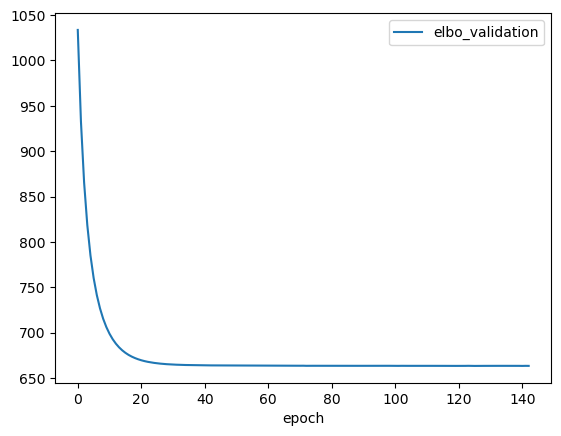

In [13]:
%%time
torch.cuda.empty_cache() 
torch.cuda.ipc_collect() 

scvi.external.CellAssign.setup_anndata(
    merge, 
    size_factor_key="size_factor",
)

model = CellAssign(merge, marker_mat)
model.train(
    max_epochs=200,
    lr=0.001,
    accelerator='gpu',
    shuffle_set_split=False,
)

model.history["elbo_validation"].plot()

In [14]:
preds = model.predict()
print(f"{preds.shape=}")
print(preds.head().to_string())

preds.shape=(128259, 55)
label  Bladder-capillary Endothelial Cell  Bladder-endothelial Cell Of Lymphatic Vessel  Bladder-fibroblast  Bladder-vein Endothelial Cell  Blood-hematopoietic Stem Cell  Bone Marrow-hematopoietic Stem Cell  Large Intestine-fibroblast  Large Intestine-gut Endothelial Cell  Lung-alveolar Fibroblast  Lung-capillary Endothelial Cell  Lung-endothelial Cell Of Artery  Lung-endothelial Cell Of Lymphatic Vessel  Lung-lung Microvascular Endothelial Cell  Lung-vein Endothelial Cell  Lung-fibroblast  Lymph Node-endothelial Cell  Lymph Node-hematopoietic Stem Cell  Mammary-endothelial Cell Of Artery  Mammary-endothelial Cell Of Lymphatic Vessel  Mammary-fibroblast Of Breast  Pancreas-endothelial Cell  Pancreas-fibroblast  Prostate-endothelial Cell  Prostate-fibroblast  Salivary Gland-endothelial Cell  Salivary Gland-endothelial Cell Of Lymphatic Vessel  Salivary Gland-fibroblast  Skin-endothelial Cell  Small Intestine-fibroblast  Small Intestine-gut Endothelial Cell  Sple

In [16]:
# break

In [17]:
# Get counts
pred_counts = preds.idxmax(axis=1).value_counts().rename("predicted")
true_counts = merge.obs['basename'].value_counts().rename("true")

# Combine counts
df_counts = pd.concat([true_counts, pred_counts], axis=1).fillna(0).astype(int)

# Add difference (count)
df_counts["difference"] = df_counts["predicted"] - df_counts["true"]

# Add percentages
df_counts["true_pct"] = df_counts["true"] / df_counts["true"].sum() * 100
df_counts["predicted_pct"] = df_counts["predicted"] / df_counts["predicted"].sum() * 100
df_counts["pct_diff"] = df_counts["predicted_pct"] - df_counts["true_pct"]

# Optional: sort
df_counts["abs_pct_diff"] = df_counts["pct_diff"].abs()
df_counts = df_counts.sort_values("abs_pct_diff", ascending=False).drop(columns="abs_pct_diff")

# Format percentages to 1 decimal place
df_counts["true_pct"] = df_counts["true_pct"].round(1)
df_counts["predicted_pct"] = df_counts["predicted_pct"].round(1)
df_counts["pct_diff"] = df_counts["pct_diff"].round(1)

print(df_counts.to_string())

                                                      true  predicted  difference  true_pct  predicted_pct  pct_diff
Uterus-fibroblast                                        0      21220       21220       0.0           16.5      16.5
Blood-hematopoietic Stem Cell                            0      20177       20177       0.0           15.7      15.7
myeloid_cells                                        20115          0      -20115      15.7            0.0     -15.7
lymphoid_cells                                       20000          0      -20000      15.6            0.0     -15.6
endothelial_cells                                    19978          0      -19978      15.6            0.0     -15.6
fibroblasts                                          19973          0      -19973      15.6            0.0     -15.6
mesenchymal_cells                                    19845          0      -19845      15.5            0.0     -15.5
Vasculature-endothelial Cell                             0      

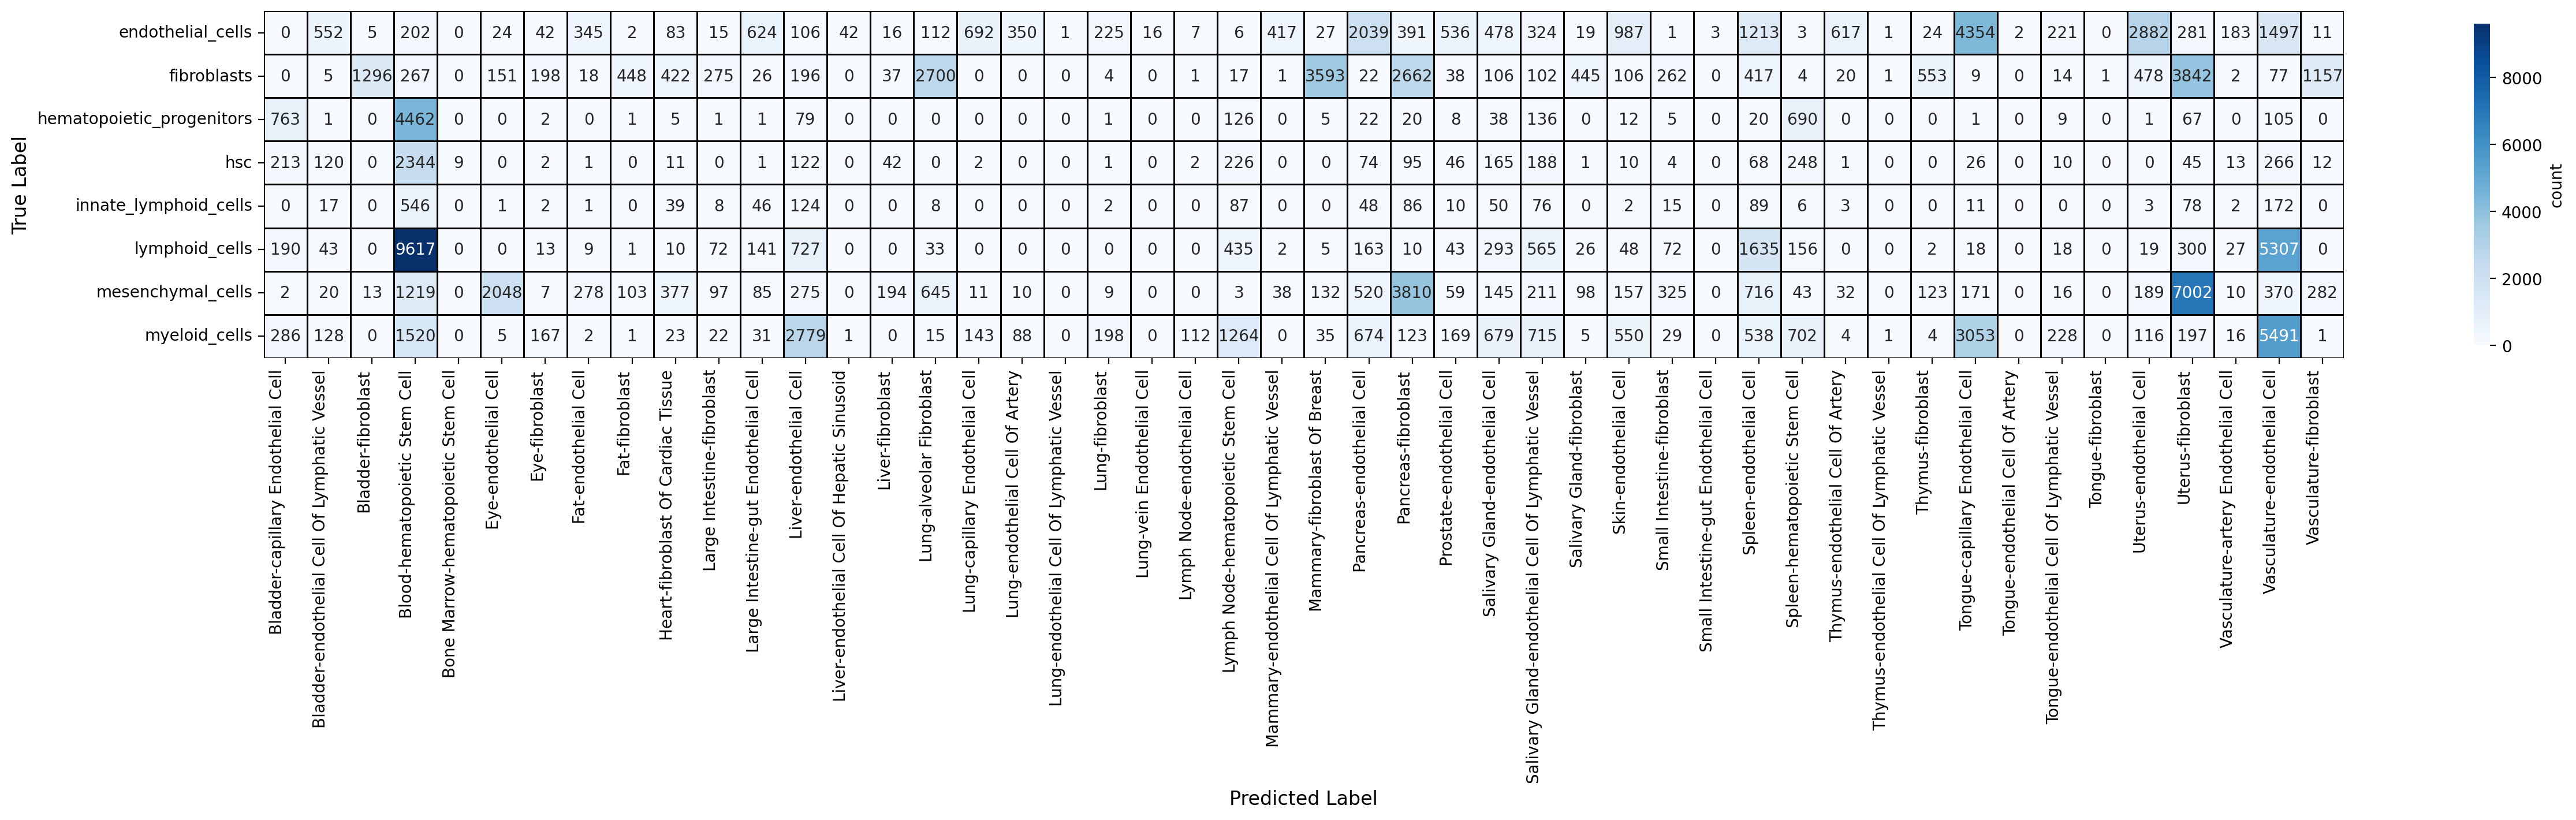

In [22]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    merge.obs['basename'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

confusion_matrix.drop(columns=['bj_fibroblast_control', 'reprogram'], inplace=True)
# confusion_matrix /= confusion_matrix.sum(1).ravel().reshape(-1, 1)
# Plot
fig, ax = plt.subplots(figsize=(25, 9))  # Square aspect
plt.rcParams['figure.dpi'] = 200
sns.heatmap(
    confusion_matrix.T,
    ax=ax,
    square=True,
    cmap="Blues",  # Use "viridis" or "mako" for alternatives
    cbar_kws={"label": "count", "shrink": 0.4},
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor='k'
)

# Aesthetics
ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

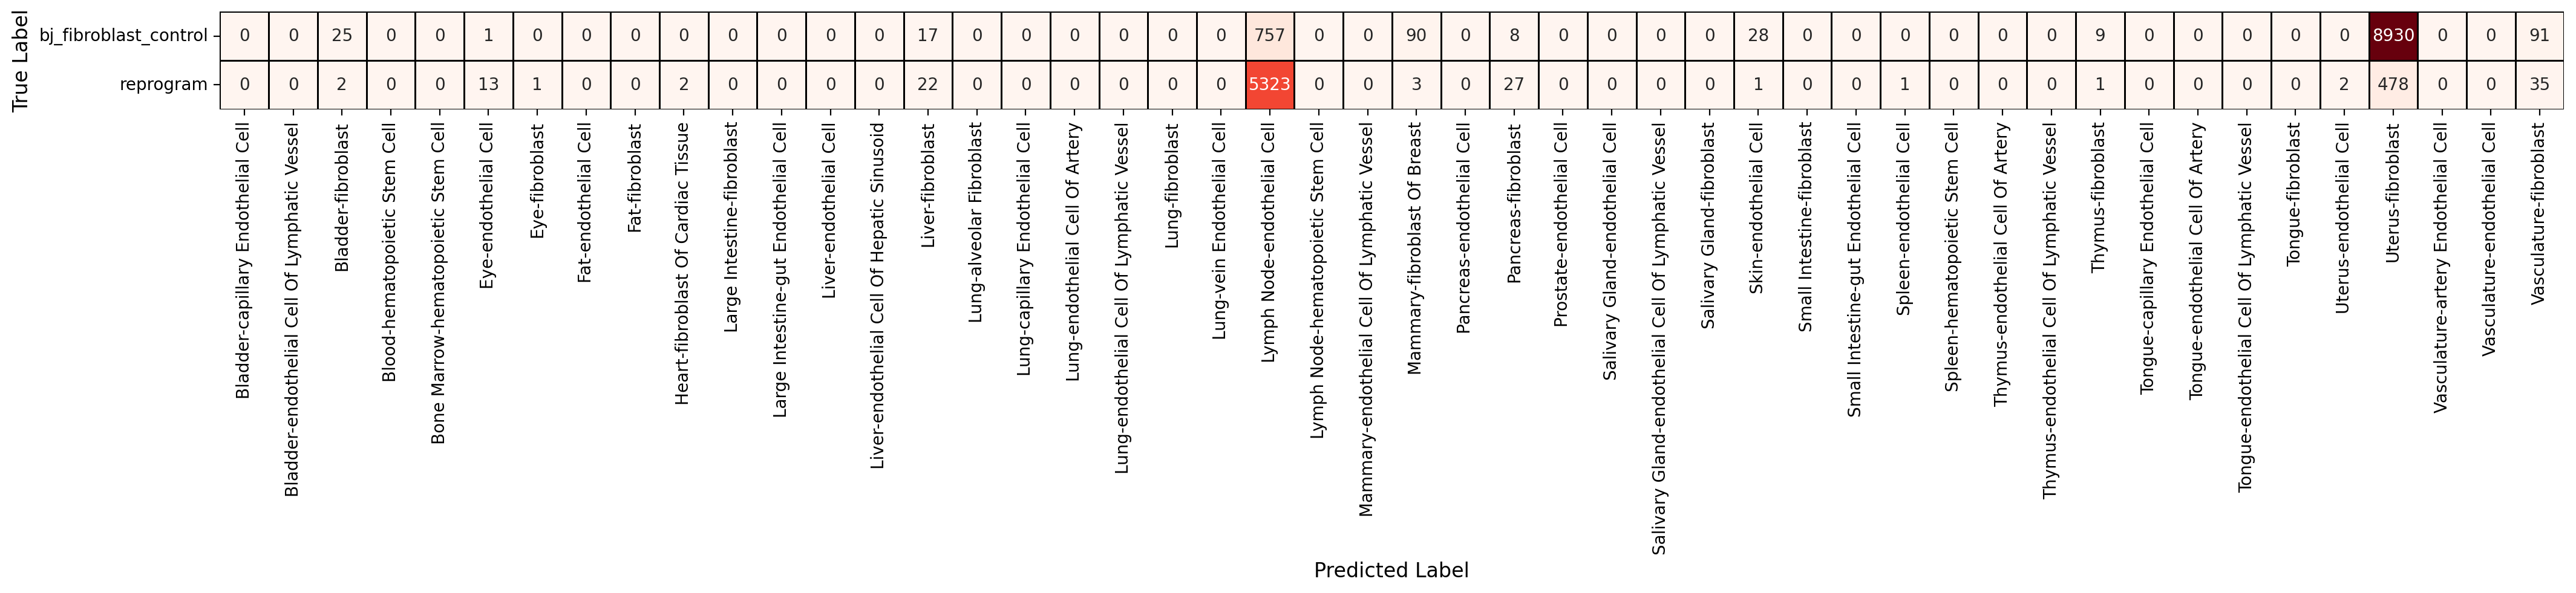

In [23]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    merge.obs['basename'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

confusion_matrix = confusion_matrix[['bj_fibroblast_control', 'reprogram']]
confusion_matrix

# Plot
plt.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots(figsize=(25, 3))  # Square aspect
sns.heatmap(
    confusion_matrix.T,
    ax=ax,
    square=True,
    cmap="Reds",  # Use "viridis" or "mako" for alternatives
    cbar=False,
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor='k'
)

# # Aesthetics
ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
plt.show()

In [20]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Differences in p(X)?

In [24]:
for col in preds.columns:
    merge.obs[col] = preds[col].values

merge

AnnData object with n_obs × n_vars = 128259 × 390
    obs: 'cell_type', 'basename', 'n_counts', 'n_genes', 'size_factor', 'batch', '_scvi_batch', 'Bladder-capillary Endothelial Cell', 'Bladder-endothelial Cell Of Lymphatic Vessel', 'Bladder-fibroblast', 'Bladder-vein Endothelial Cell', 'Blood-hematopoietic Stem Cell', 'Bone Marrow-hematopoietic Stem Cell', 'Large Intestine-fibroblast', 'Large Intestine-gut Endothelial Cell', 'Lung-alveolar Fibroblast', 'Lung-capillary Endothelial Cell', 'Lung-endothelial Cell Of Artery', 'Lung-endothelial Cell Of Lymphatic Vessel', 'Lung-lung Microvascular Endothelial Cell', 'Lung-vein Endothelial Cell', 'Lung-fibroblast', 'Lymph Node-endothelial Cell', 'Lymph Node-hematopoietic Stem Cell', 'Mammary-endothelial Cell Of Artery', 'Mammary-endothelial Cell Of Lymphatic Vessel', 'Mammary-fibroblast Of Breast', 'Pancreas-endothelial Cell', 'Pancreas-fibroblast', 'Prostate-endothelial Cell', 'Prostate-fibroblast', 'Salivary Gland-endothelial Cell', 'Salivary

In [ ]:
# merge.obs['hsc']

<Axes: xlabel='Lymph Node-endothelial Cell', ylabel='basename'>

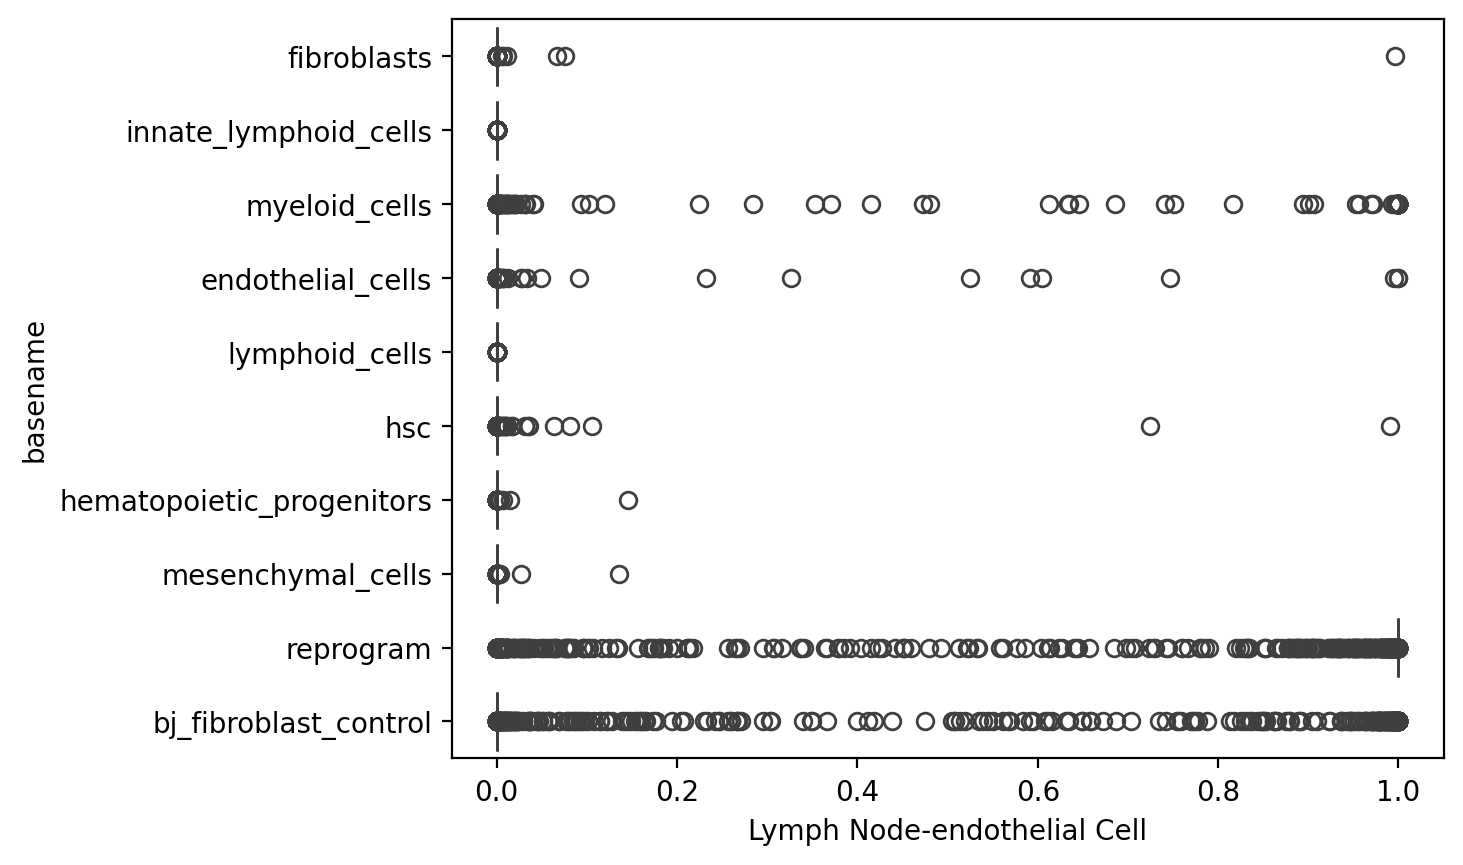

In [25]:
sns.boxplot(
    data=merge.obs,
    y='basename',
    x='Lymph Node-endothelial Cell',
)

# New Embedding

In [ ]:
%%time
rsc.get.anndata_to_GPU(merge) # move to GPU

rsc.pp.pca(merge)
rsc.pp.harmony_integrate(merge, key='batch', correction_method='fast')
rsc.pp.neighbors(merge, n_neighbors=1000, use_rep='X_pca_harmony')
# sc.tl.paga(merge, groups='basename')
# sc.pl.paga(merge)


rsc.tl.draw_graph(
    merge,
    # init_pos='paga'
)


sc.pl.draw_graph(
    merge, 
    color=["basename"],
    size=15,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)


# differences in probability?

In [ ]:
for col in preds.columns:
    merge.obs[col] = preds[col]

merge

In [ ]:
break

# Embedding

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.25, 4.75

adata.obs['prediction'] = preds.idxmax(axis=1).values

sc.pl.tsne(
    adata,
    color=['basename', 'prediction'],
    size=35,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.75,
    palette=adata.uns['basename_palette'],
)

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.75, 4.75

adata.obs['p(x)'] = preds.max(axis=1).fillna(0.0).values
min_val = adata.obs['p(x)'].min()
max_val = adata.obs['p(x)'].max()
adata.obs['p(x)_reversed_norm'] = (max_val - adata.obs['p(x)']) / (max_val - min_val)

sc.pl.tsne(
    adata,
    color=['p(x)_reversed_norm'],
    sort_order=True,
    size=32,
    ncols=4,
    alpha=0.75,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.75,
    title=['uncertainty'],
    cmap='inferno',
)

In [ ]:
break

# with pangloa

In [ ]:
print(torch.cuda.memory_allocated() / 1e6, "MB allocated")
print(torch.cuda.memory_reserved() / 1e6, "MB reserved")

In [ ]:
def load_pathway(fpath):
    """
    Loads an Enrichr-like database file into a boolean DataFrame.

    Args:
        fpath (str): Path to the Enrichr-like database file.

    Returns:
        pandas.DataFrame: A boolean DataFrame where:
            - Index: Genes
            - Columns: Pathways
            - Values: True if the gene is in the pathway, False otherwise.
    """

    result = []
    with open(fpath,  encoding='utf-8') as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

fpath = "../../resources/PanglaoDB_Augmented_2021.txt"
pdf = load_pathway(fpath)
cell_types = ['Hematopoietic Stem Cells', 'Endothelial Cells', 'Fibroblasts']

pdf = pdf[pdf[cell_types].any(axis=1)][cell_types]
print(f"Raw: {pdf.shape=}")
pdf = pdf.astype(int)
pdf = pdf[pdf.index.isin(raw_adata.var_names)]
print(f"Filtered: {pdf.shape=}")
pdf.head()

# Sampling

In [ ]:
fraction = 0.15
adata = raw_adata.copy()
adata = adata[:, pdf.index].copy()
adata = sc.pp.subsample(adata, fraction=fraction, copy=True)
print(f"Filtered: {raw_adata.shape=}")

adata

In [ ]:
%%time
torch.cuda.empty_cache() 
torch.cuda.ipc_collect() 

scvi.external.CellAssign.setup_anndata(
    adata, 
    size_factor_key="size_factor",
    layer='counts',
)

model = CellAssign(adata, marker_mat)
model.train(
    max_epochs=200,
    lr=0.001,
    accelerator='gpu',
    shuffle_set_split=False,
)

model.history["elbo_validation"].plot()

In [ ]:
preds = model.predict()
print(f"{preds.shape=}")
print(preds.head().to_string())

In [ ]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    adata.obs['basename'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

confusion_matrix /= confusion_matrix.sum(1).ravel().reshape(-1, 1)
# Plot
fig, ax = plt.subplots(figsize=(9, 9))  # Square aspect
sns.heatmap(
    confusion_matrix,
    ax=ax,
    square=True,
    cmap="Blues",  # Use "viridis" or "mako" for alternatives
    cbar_kws={"label": "proportion", "shrink": 0.4},
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='k'
)

# Aesthetics
ax.set_xlabel("True Label", fontsize=12)
ax.set_ylabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.25, 4.75

adata.obs['prediction'] = preds.idxmax(axis=1).values

sc.pl.tsne(
    adata,
    color=['basename', 'prediction'],
    size=35,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.75,
    palette=adata.uns['basename_palette'],
)